In [252]:
#Loading Libraries

import pandas as pd
import numpy as np
import duckdb as db
import skimpy as sk
import seaborn as sns
import matplotlib.pyplot as plt


In [253]:
#Loading Dataset

data = pd.read_csv("Datasets\\Unclean_Student_Records.csv",encoding='ISO-8859-1')


In [254]:
#Cleaning Column_Names

data.columns = [x.strip().lower() for x in data.columns]

Data Quality Overview

In [255]:
data.columns

Index(['student_id', 'first_name', 'last_name', 'age', 'gender', 'course',
       'enrollment_date', 'total_payments'],
      dtype='object')

In [256]:
data.head()

,student_id,first_name,last_name,age,gender,course,enrollment_date,total_payments
0,101 | John | Smith | 22 | M ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,102 | Emily | Johnson | 24 | F ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,103 | Michael | Williams | 21 | M ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,104 | Sarah | Brown | 23 | F ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105 | David | Davis | 20 | M ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [257]:
sk.skim(data)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 136    │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 8      │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓  │
│ ┃           ┃     ┃          ┃          ┃           ┃          ┃           ┃ chars    ┃ words per ┃ total    ┃  │
│ ┃ column    ┃ NA  ┃ NA %     ┃ shortest ┃ longest   ┃ min      ┃ max       ┃ per row  ┃ row       ┃ words    ┃  │
│ ┡━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩  │
│ │ student_i │   4 │ 2.941176 │ Lay      │ 149       │       |  │ Zainab    │       59 │        25 │     3459 │  │
│ │ d         │     │ 47058823 │          │ | Ava     │ Ben   |  │ Adeyemi   │          │           │          │  │
│ │           │     │       55 │          │ | Miller  │ Thompson │           │          │           │          │  │
│ │           │     │          │          │ | 25  | F │ | 20  |  │           │          │           │          │  │
│ │           │     │          │          │ | Machine │ M      | │           │          │           │          │  │
│ │           │     │          │          │ Learning  │ Web      │           │          │           │          │  │
│ │           │     │          │          │ |         │ Developm │           │          │           │          │  │
│ │           │     │          │          │ 2022-04-2 │ ent  |   │           │          │           │          │  │
│ │           │     │          │          │ 2      |  │ 2022-11- │           │          │           │          │  │
│ │           │     │          │          │ $1300     │ 14       │           │          │           │          │  │
│ │           │     │          │          │           │ | $1050  │           │          │           │          │  │
│ │ first_nam │  37 │ 27.20588 │ Lay      │ 149       │       |  │ Zainab    │     45.9 │        14 │     1943 │  │
│ │ e         │     │ 23529411 │          │ | Ava     │ Ben   |  │ Adeyemi   │          │           │          │  │
│ │           │     │       78 │          │ | Miller  │ Thompson │           │          │           │          │  │
│ │           │     │          │          │ | 25  | F │ | 20  |  │           │          │           │          │  │
│ │           │     │          │          │ | Machine │ M      | │           │          │           │          │  │
│ │           │     │          │          │ Learning  │ Web      │           │          │           │          │  │
│ │           │     │          │          │ |         │ Developm │           │          │           │          │  │
│ │           │     │          │          │ 2022-04-2 │ ent  |   │           │          │           │          │  │
│ │           │     │          │          │ 2      |  │ 2022-11- │           │          │           │          │  │
│ │           │     │          │          │ $1300     │ 14       │           │          │           │          │  │
│ │           │     │          │          │           │ 

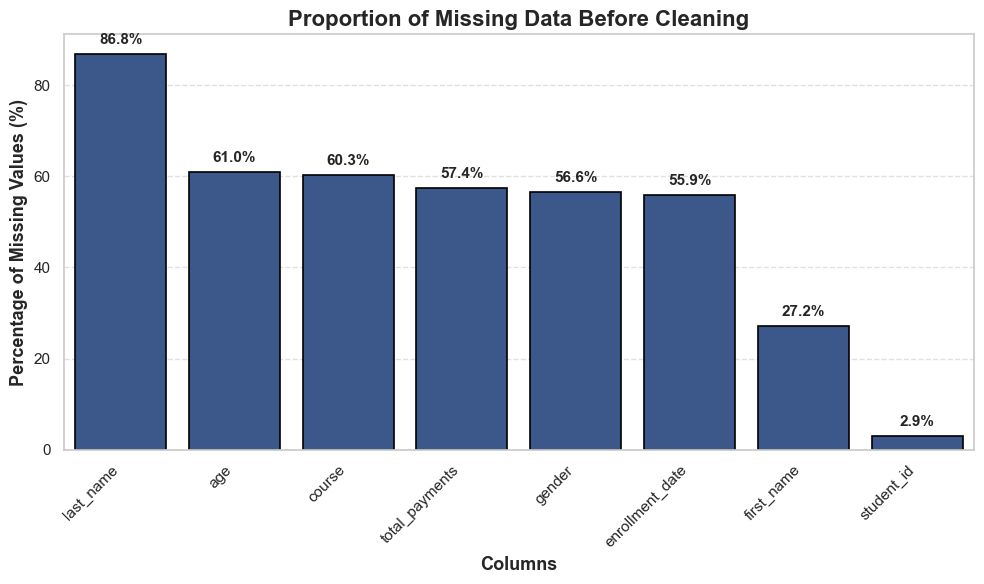

In [258]:
# -------------------------
# Calculate missing percentages
# -------------------------
missing_percent = (data.isnull().sum() / len(data)) * 100

missing_data = (
    missing_percent
    .sort_values(ascending=False)
    .reset_index()
)

missing_data.columns = ["Column", "Missing_Percentage"]

# -------------------------
# Visualization
# -------------------------
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=missing_data,
    x="Column",
    y="Missing_Percentage",
    color="#2F5597",
    edgecolor="black",
    linewidth=1.2
)

# Titles and labels
plt.title("Proportion of Missing Data Before Cleaning", fontsize=16, weight="bold")
plt.xlabel("Columns", fontsize=13, weight="bold")
plt.ylabel("Percentage of Missing Values (%)", fontsize=13, weight="bold")

plt.xticks(rotation=45, ha="right")

# Improve grid visibility
ax.grid(axis="y", linestyle="--", alpha=0.6)

# -------------------------
# Annotate bars clearly
# -------------------------
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1f}%",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=11,
        weight="bold",
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

In [259]:
#Load dataset into duckdb for sql-based transformations

con = db.connect()

con.execute("CREATE OR REPLACE TABLE df AS SELECT * FROM data")


Removing Whitespaces

In [260]:
con.execute("""Update df set 
            student_id = trim(student_id),
            first_name = trim(first_name),
            last_name = trim(last_name),
            age  = trim(age),
            gender = trim(gender),
            course = trim(course),
            enrollment_date = trim(enrollment_date),
            total_payments = trim(total_payments)
            """)

Data Distribution Functions

In [261]:
con.execute("""
UPDATE df
SET
    student_id = SPLIT_PART(raw_data, '|', 1),
    first_name = SPLIT_PART(raw_data, '|', 2),
    last_name = SPLIT_PART(raw_data, '|', 3),
    age = SPLIT_PART(raw_data, '|', 4),
    gender = SPLIT_PART(raw_data, '|', 5),
    course = SPLIT_PART(raw_data, '|', 6),
    enrollment_date = SPLIT_PART(raw_data, '|', 7),
    total_payments = SPLIT_PART(raw_data, '|', 8)
FROM (
    SELECT
        student_id,
        first_name,
        CASE
            WHEN student_id LIKE '%|%' THEN student_id
            WHEN first_name LIKE '%|%' THEN first_name
        END AS raw_data
    FROM df
    WHERE student_id LIKE '%|%' OR first_name LIKE '%|%'
) src
WHERE df.student_id = src.student_id OR df.first_name = src.first_name;
""")

In [262]:
con.query("SELECT * FROM df ").df().head(15)

,student_id,first_name,last_name,age,gender,course,enrollment_date,total_payments
0,101,John,Smith,22,M,Data Science,2022-05-15,$1200
1,102,Emily,Johnson,24,F,Machine Learnin,2022-03-18,$1400
2,103,Michael,Williams,21,M,Data Science,2022-06-25,$900
3,104,Sarah,Brown,23,F,Data Science,NA,$1100
4,105,David,Davis,20,M,Web Developmen,2021-09-10,$950
5,106,Jessica,Miller,25,F,Machine Learnin,2022-04-22,$1300
6,107,Brian,Wilson,19,M,Data Science,2022-07-02,$1000
7,108,Amanda,Taylor,22,F,Machine Learnin,2022-08-15,$1200
8,109,William,Anderson,24,M,Data Science,2022-01-10,$950
9,110,Olivia,Martinez,26,F,Data Science,2023-02-28,$1150


Standardizing Values

In [263]:
con.query("Select distinct(course) from df")

┌────────────────────┐
│       course       │
│      varchar       │
├────────────────────┤
│  Data Science      │
│ Data Analytics     │
│ Web Developmet     │
│  Web Development   │
│  Web Developmen    │
│  Web Development   │
│ NULL               │
│  Data Science      │
│  Data Science      │
│ Data Analysis      │
│ Web Develpment     │
│  Machine Learning  │
│ 4                  │
│ Machine Learning   │
│  Machine Learning  │
│ Web Development    │
│  Machine Learnin   │
│ Cyber Security     │
├────────────────────┤
│      18 rows       │
└────────────────────┘

In [264]:
con.query("""Update df 
set course = case 
          When course like '%Data S%' Then 'Data Science'
          When course like '%Web%' Then 'Web Development'
          When course like '%Data A%' Then 'Data Analytics'
          When course like '%4%' Then 'Course No.4'
          When course like '%Machine%' Then 'Machine Learning'
          ELSE course
        END
""")



In [265]:
con.query("Select distinct(course) from df")

┌──────────────────┐
│      course      │
│     varchar      │
├──────────────────┤
│ Data Science     │
│ Data Analytics   │
│ Course No.4      │
│ Machine Learning │
│ Web Development  │
│ Cyber Security   │
│ NULL             │
└──────────────────┘

In [266]:
con.query("Select distinct(age) from df")

┌─────────┐
│   age   │
│ varchar │
├─────────┤
│  24     │
│  23     │
│  25     │
│  26     │
│ 23      │
│ 21      │
│ 19      │
│ 40      │
│ 18      │
│  20     │
│  19     │
│ M       │
│ 78*     │
│ 4       │
│ F       │
│ 22      │
│ 21*     │
│ 20      │
│ 25      │
│  22     │
│  21     │
│ NULL    │
├─────────┤
│ 22 rows │
└─────────┘

In [267]:
con.query("Select * from df where age is null and gender is not null")

┌──────────────────┬──────────────────┬───────────┬─────────┬─────────┬─────────────────┬─────────────────┬────────────────┐
│    student_id    │    first_name    │ last_name │   age   │ gender  │     course      │ enrollment_date │ total_payments │
│     varchar      │     varchar      │  varchar  │ varchar │ varchar │     varchar     │     varchar     │    varchar     │
├──────────────────┼──────────────────┼───────────┼─────────┼─────────┼─────────────────┼─────────────────┼────────────────┤
│ Davis            │ Davis            │ Brown     │ NULL    │ M 25    │ Data Analytics  │ 05-09-23        │ ?20,000.00     │
│ Anita            │ Anita            │ West      │ NULL    │ F 24    │ Course No.4     │ 05-01-20        │ ?30,000.00     │
│ Olawale Akintola │ Olawale Akintola │ NULL      │ NULL    │ M 20    │ Web Development │ 05-08-21        │ ?30,000.00     │
│ Wike             │ Wike             │ Akintola  │ NULL    │ M 25    │ NULL            │ 06-05-22        │ ?36,000.00     │


In [268]:
# =====================================
# STUDENT DATA CLEANING PIPELINE
# =====================================

# -------------------------
# Step 1: Uppercase gender
# -------------------------
con.query("""
UPDATE df
SET gender = UPPER(TRIM(gender))
WHERE gender IS NOT NULL;
""")

# -------------------------
# Step 2: Extract age from combined gender-age strings (e.g., 'F 24')
# -------------------------
con.query("""
UPDATE df
SET age = RIGHT(TRIM(gender), 2)
WHERE age IS NULL
  AND gender IS NOT NULL
  AND LENGTH(TRIM(gender)) > 1;
""")

# -------------------------
# Step 3: Swap age and gender if age contains letters (incorrect entries)
# -------------------------
con.query("""
UPDATE df
SET
    age = CASE WHEN age ~ '[A-Za-z]' THEN gender ELSE age END,
    gender = CASE WHEN age ~ '[A-Za-z]' THEN age ELSE gender END
WHERE age ~ '[A-Za-z]';
""")

# -------------------------
# Step 4: Remove asterisks from age
# -------------------------
con.query("""
UPDATE df
SET age = REPLACE(age, '*', '');
""")

# -------------------------
# Step 5: Trim extra spaces from age
# -------------------------
con.query("""
UPDATE df
SET age = TRIM(age);
""")

# -------------------------
# Step 6: Convert age column to INTEGER type
# -------------------------
con.query("""
ALTER TABLE df
ALTER COLUMN age SET DATA TYPE INTEGER;
""")

# -------------------------
# Step 7: Ensure gender only contains 'M' or 'F'
# -------------------------
con.query("""
UPDATE df
SET gender = NULL
WHERE gender NOT IN ('M','F');
""")

In [269]:
con.query("Select distinct(gender) from df")

┌─────────┐
│ gender  │
│ varchar │
├─────────┤
│ M       │
│ F       │
│ NULL    │
└─────────┘

In [270]:
con.execute("""
DELETE FROM df
WHERE age < 18;
""")

In [271]:
con.query("Select distinct(age)  from df")

┌───────┐
│  age  │
│ int32 │
├───────┤
│    21 │
│    20 │
│    19 │
│    26 │
│    18 │
│    23 │
│    25 │
│    24 │
│    40 │
│    22 │
│  NULL │
│    78 │
└───────┘

In [272]:
con.query("Update df set enrollment_date = NULL where enrollment_date like '%NA%'")

In [273]:
con.query("Select distinct(enrollment_date) from df ")

┌───────────────────┐
│  enrollment_date  │
│      varchar      │
├───────────────────┤
│ 06-05-22          │
│ 08-01-22          │
│ 02-05-99          │
│ 10-Jul-20         │
│ 01-Jul-22         │
│ 01-Jul-24         │
│ 28-Aug-22         │
│ 25-Sep-20         │
│ NULL              │
│  2022-07-02       │
│     ·             │
│     ·             │
│     ·             │
│ 01-Sep-20         │
│ 06-Aug-22         │
│ 12-Jul-23         │
│ 07-Oct-22         │
│ 06-Jul-22         │
│ 02-Sep-23         │
│ 31-Aug-23         │
│  2022-02-03       │
│  2022-05-09       │
│  2023-01-15       │
├───────────────────┤
│      69 rows      │
│    (20 shown)     │
└───────────────────┘

In [274]:

con.execute("""WITH CTE AS (
    SELECT * FROM df
)
SELECT 
    enrollment_date,
    SPLIT_PART(enrollment_date, '-', 1) AS year,
    CASE 
        -- Check if the first part of the date is a 4-digit year starting with '20'
        WHEN SPLIT_PART(enrollment_date, '-', 1) LIKE '20__' 
             AND LENGTH(SPLIT_PART(enrollment_date, '-', 1)) = 4
             AND SPLIT_PART(enrollment_date, '-', 2) IS NOT NULL
             AND SPLIT_PART(enrollment_date, '-', 3) IS NOT NULL
            THEN 'Year-Month-Day'  -- Format: YYYY-MM-DD
        ELSE 'Other Format'  -- Any other format
    END AS Format_Check,
    
    -- Reformat the date to DD-MM-YYYY if it matches the YYYY-MM-DD pattern
    CASE 
        WHEN enrollment_date LIKE '20__-%' THEN 
            STRFTIME(STRPTIME(TRIM(enrollment_date), '%Y-%m-%d'), '%d-%m-%Y')
        ELSE  enrollment_date-- Keep it as-is if it doesn't match
    END AS Reformatted_Date

FROM CTE;""").df()



,enrollment_date,year,Format_Check,Reformatted_Date
0,2022-05-15,2022,Other Format,2022-05-15
1,2022-03-18,2022,Other Format,2022-03-18
2,2022-06-25,2022,Other Format,2022-06-25
3,None,None,Other Format,None
4,2021-09-10,2021,Other Format,2021-09-10
...,...,...,...,...
130,2022-08-12,2022,Other Format,2022-08-12
131,2022-02-03,2022,Other Format,2022-02-03
132,2022-07-21,2022,Other Format,2022-07-21
133,2022-05-09,2022,Other Format,2022-05-09


In [275]:

con.execute("""
UPDATE df
SET enrollment_date = TRIM(enrollment_date)
WHERE enrollment_date IS NOT NULL AND enrollment_date <> '';
""")

con.execute("""
UPDATE df
SET enrollment_date = STRFTIME(STRPTIME(enrollment_date, '%d-%b-%y'), '%d-%m-%Y')
WHERE REGEXP_MATCHES(enrollment_date, '^[0-9]{2}-[A-Za-z]{3}-[0-9]{2}$');
""")


con.execute("""
UPDATE df
SET enrollment_date = STRFTIME(STRPTIME(enrollment_date, '%Y-%m-%d'), '%d-%m-%Y')
WHERE REGEXP_MATCHES(enrollment_date, '^20[0-9]{2}-[0-9]{2}-[0-9]{2}$');
""")

con.execute("""
UPDATE df
SET enrollment_date = STRFTIME(STRPTIME(enrollment_date, '%d-%m-%y'), '%d-%m-%Y')
WHERE REGEXP_MATCHES(enrollment_date, '^[0-9]{2}-[0-9]{2}-[0-9]{2}$');
""")

Imputation

In [276]:
con.execute("ALTER Table df add column currency varchar")


con.execute("""
UPDATE df
SET currency = CASE
    WHEN total_payments LIKE '%$%' THEN 'USD'
    WHEN total_payments LIKE '%£%' THEN 'GBP'
    WHEN total_payments LIKE '%€%' THEN 'EUR'
    WHEN total_payments LIKE '%R%' THEN 'ZAR'
    ELSE NULL
END
WHERE total_payments IS NOT NULL;
""")


con.execute("""
UPDATE df
SET total_payments = TRIM(
    BOTH ' ' FROM 
    REGEXP_REPLACE(total_payments, '[^0-9\\.]', '', 'g')
)
WHERE total_payments IS NOT NULL;
""")

In [277]:
con.execute("""
UPDATE df
SET student_id = Null
WHERE student_id = first_name or student_id = '' 
""")


con.execute("""
UPDATE df
SET student_id = sub.new_id
FROM (
    SELECT
        rowid AS rid,
        CONCAT('Temp-', ROW_NUMBER() OVER (ORDER BY (SELECT NULL))) AS new_id
    FROM df
    WHERE student_id IS NULL OR TRIM(student_id) = ''
) AS sub
WHERE df.rowid = sub.rid;
""")

In [278]:
con.execute("Alter table df add display_name varchar(100)")

con.execute("Update df set display_name = Trim(CONCAT(first_name,' ',last_name))")

con.execute("Alter table df drop column first_name")

con.execute("Alter table df drop column last_name")



In [279]:
con.query("Select * from df").df().columns

Index(['student_id', 'age', 'gender', 'course', 'enrollment_date',
       'total_payments', 'currency', 'display_name'],
      dtype='object')

In [280]:
final_data = con.query("Select student_id,display_name,age,gender,course,enrollment_date,total_payments,currency from df").df()

In [281]:
final_data.isnull().sum()

student_id          0
display_name        0
age                 2
gender              7
course              6
enrollment_date     7
total_payments      2
currency           55
dtype: int64

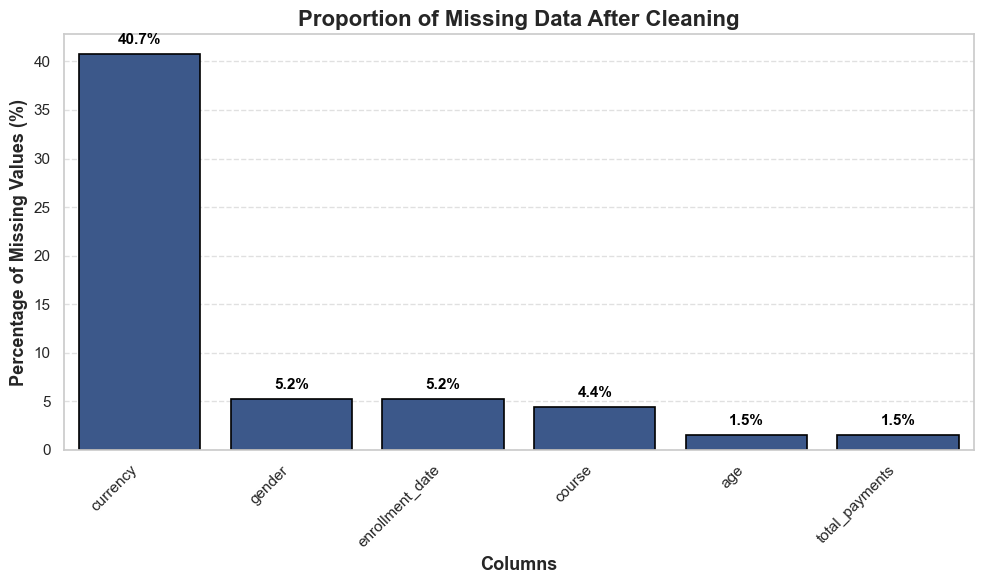

In [283]:
# -------------------------
# Calculate missing data for cleaned dataset
# -------------------------
missing_counts_clean = final_data.isnull().sum()
missing_percent_clean = (missing_counts_clean / len(final_data)) * 100

missing_data_clean = (
    missing_percent_clean[missing_percent_clean > 0]
    .sort_values(ascending=False)
    .reset_index()
)

missing_data_clean.columns = ["Column", "Missing_Percentage"]

# -------------------------
# Visualization
# -------------------------
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=missing_data_clean,
    x="Column",
    y="Missing_Percentage",
    color="#2F5597",
    edgecolor="black",
    linewidth=1.2
)

# Titles and labels
plt.title("Proportion of Missing Data After Cleaning", fontsize=16, weight="bold")
plt.xlabel("Columns", fontsize=13, weight="bold")
plt.ylabel("Percentage of Missing Values (%)", fontsize=13, weight="bold")

plt.xticks(rotation=45, ha="right")

# Improve grid visibility
ax.grid(axis="y", linestyle="--", alpha=0.6)

# -------------------------
# Annotate bars clearly
# -------------------------
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1f}%",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=11,
        weight="bold",
        color="black",
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()